In [1]:
import pandas as pd
from pathlib import Path
import re

# 1) Find all uploaded candle CSVs in /content
base = Path("/content")
candle_files = sorted(base.glob("Si*_candles_2024-01-01_2025-12-31_1m.csv"))

print(f"Found candle files: {len(candle_files)}")
for f in candle_files:
    print(" -", f.name)

# 2) Read and standardize each file
dfs = []

for f in candle_files:
    df = pd.read_csv(f)

    # Standardize column names
    df.columns = [c.strip().lower() for c in df.columns]

    # Extract contract from filename, e.g. SiH4, SiM5
    m = re.match(r"(Si[A-Z]\d+)_candles_", f.name)
    contract = m.group(1) if m else f.stem.split("_")[0]

    # Parse timestamps
    if "begin" in df.columns:
        df["begin"] = pd.to_datetime(df["begin"], errors="coerce")
    if "end" in df.columns:
        df["end"] = pd.to_datetime(df["end"], errors="coerce")

    # Add metadata
    df["contract"] = contract
    df["source_file"] = f.name

    # If secid missing, fill from contract
    if "secid" not in df.columns:
        df["secid"] = contract

    # Reorder common columns if present
    preferred_order = [
        "begin", "end", "open", "high", "low", "close",
        "volume", "value", "secid", "contract", "source_file"
    ]
    existing = [c for c in preferred_order if c in df.columns]
    others = [c for c in df.columns if c not in existing]
    df = df[existing + others]

    dfs.append(df)

# 3) Merge all into one long table
merged = pd.concat(dfs, ignore_index=True)

# 4) Clean + sort
merged = merged.dropna(subset=["begin"]).sort_values(["contract", "begin"]).reset_index(drop=True)

# 5) Save merged file
out_path = "/content/si_candles_merged_long.csv"
merged.to_csv(out_path, index=False)

# 6) Print useful checks
print("\nMerged shape:", merged.shape)
print("Saved to:", out_path)

print("\nColumns:")
print(list(merged.columns))

print("\nOverall date range:")
print("begin min:", merged["begin"].min())
print("begin max:", merged["begin"].max())

summary = (
    merged.groupby("contract")
    .agg(
        rows=("begin", "size"),
        begin_min=("begin", "min"),
        begin_max=("begin", "max"),
    )
    .reset_index()
    .sort_values("contract")
)

print("\nPer-contract summary:")
print(summary.to_string(index=False))

print("\nHead:")
print(merged.head(10).to_string(index=False))

Found candle files: 14
 - SiH4_candles_2024-01-01_2025-12-31_1m.csv
 - SiH5_candles_2024-01-01_2025-12-31_1m.csv
 - SiH6_candles_2024-01-01_2025-12-31_1m.csv
 - SiH7_candles_2024-01-01_2025-12-31_1m.csv
 - SiM4_candles_2024-01-01_2025-12-31_1m.csv
 - SiM5_candles_2024-01-01_2025-12-31_1m.csv
 - SiM6_candles_2024-01-01_2025-12-31_1m.csv
 - SiM7_candles_2024-01-01_2025-12-31_1m.csv
 - SiU4_candles_2024-01-01_2025-12-31_1m.csv
 - SiU5_candles_2024-01-01_2025-12-31_1m.csv
 - SiU6_candles_2024-01-01_2025-12-31_1m.csv
 - SiZ4_candles_2024-01-01_2025-12-31_1m.csv
 - SiZ5_candles_2024-01-01_2025-12-31_1m.csv
 - SiZ6_candles_2024-01-01_2025-12-31_1m.csv

Merged shape: (775621, 11)
Saved to: /content/si_candles_merged_long.csv

Columns:
['begin', 'end', 'open', 'high', 'low', 'close', 'volume', 'value', 'secid', 'contract', 'source_file']

Overall date range:
begin min: 2024-01-03 08:59:00
begin max: 2025-12-30 18:14:00

Per-contract summary:
contract   rows           begin_min           begin_m

In [2]:
import pandas as pd

# 1) Load merged long file
df = pd.read_csv("/content/si_candles_merged_long.csv")
df["begin"] = pd.to_datetime(df["begin"])
df["end"] = pd.to_datetime(df["end"])

print("Loaded shape:", df.shape)

# 2) Keep only needed columns
cols = ["begin", "open", "high", "low", "close", "volume", "value", "secid", "contract"]
df = df[cols].copy()

# 3) Resample each contract to 15-minute OHLCV
resampled_parts = []

for contract, g in df.groupby("contract", sort=True):
    g = g.sort_values("begin").set_index("begin")

    r = g.resample("15min").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum",
        "value": "sum",
        "secid": "first",
        "contract": "first",
    })

    # keep only bars that actually have trading data
    r = r.dropna(subset=["open", "high", "low", "close"])

    r = r.reset_index()
    resampled_parts.append(r)

df_15m = pd.concat(resampled_parts, ignore_index=True)
df_15m = df_15m.sort_values(["contract", "begin"]).reset_index(drop=True)

# 4) Save
out_path = "/content/si_candles_15m_by_contract.csv"
df_15m.to_csv(out_path, index=False)

# 5) Output checks
print("\n15m shape:", df_15m.shape)
print("Saved to:", out_path)

print("\nColumns:")
print(list(df_15m.columns))

print("\nOverall 15m date range:")
print("begin min:", df_15m["begin"].min())
print("begin max:", df_15m["begin"].max())

summary_15m = (
    df_15m.groupby("contract")
    .agg(
        rows_15m=("begin", "size"),
        begin_min=("begin", "min"),
        begin_max=("begin", "max"),
        total_volume=("volume", "sum"),
    )
    .reset_index()
    .sort_values("contract")
)

print("\nPer-contract 15m summary:")
print(summary_15m.to_string(index=False))

print("\nHead:")
print(df_15m.head(10).to_string(index=False))

Loaded shape: (775621, 11)

15m shape: (89628, 9)
Saved to: /content/si_candles_15m_by_contract.csv

Columns:
['begin', 'open', 'high', 'low', 'close', 'volume', 'value', 'secid', 'contract']

Overall 15m date range:
begin min: 2024-01-03 08:45:00
begin max: 2025-12-30 18:00:00

Per-contract 15m summary:
contract  rows_15m           begin_min           begin_max  total_volume
    SiH4      3315 2024-01-03 08:45:00 2024-03-21 13:45:00      44049417
    SiH5     12139 2024-01-03 09:00:00 2025-03-20 18:45:00      50118846
    SiH6      2555 2024-03-15 10:00:00 2025-12-01 17:30:00         99259
    SiH7       575 2025-03-14 16:30:00 2025-12-30 18:00:00          1529
    SiM4      7101 2024-01-03 08:45:00 2024-06-20 13:45:00      45439223
    SiM5     11111 2024-01-03 09:00:00 2025-06-19 18:45:00      49801475
    SiM6      2019 2024-06-25 10:00:00 2025-12-04 10:15:00         12669
    SiM7       368 2025-06-20 11:30:00 2025-12-30 18:00:00          1324
    SiU4      9514 2024-01-03 08:45:0

In [3]:
import pandas as pd

# 1) Load 15m contract data
df = pd.read_csv("/content/si_candles_15m_by_contract.csv")
df["begin"] = pd.to_datetime(df["begin"])

print("Loaded 15m shape:", df.shape)

# 2) Add trading date
df["trade_date"] = df["begin"].dt.date

# 3) Compute daily total volume by contract
daily_vol = (
    df.groupby(["trade_date", "contract"], as_index=False)
      .agg(day_volume=("volume", "sum"),
           bars=("begin", "size"))
)

# 4) Pick front contract per day = highest daily volume
front_daily = (
    daily_vol.sort_values(["trade_date", "day_volume", "contract"], ascending=[True, False, True])
             .drop_duplicates(subset=["trade_date"], keep="first")
             .sort_values("trade_date")
             .reset_index(drop=True)
)

# 5) Merge front contract choice back to 15m bars
front_map = front_daily[["trade_date", "contract"]].rename(columns={"contract": "front_contract"})
df_front = df.merge(front_map, on="trade_date", how="left")

# 6) Keep only bars from the chosen front contract of that day
continuous_15m = (
    df_front[df_front["contract"] == df_front["front_contract"]]
    .copy()
    .sort_values("begin")
    .reset_index(drop=True)
)

# 7) Add helpful columns
continuous_15m["is_roll_day"] = continuous_15m["front_contract"] != continuous_15m["front_contract"].shift(1)
continuous_15m.loc[0, "is_roll_day"] = True

roll_table = (
    front_daily.copy()
    .assign(prev_contract=front_daily["contract"].shift(1))
)
roll_table["is_roll_day"] = roll_table["contract"] != roll_table["prev_contract"]
roll_table.loc[0, "is_roll_day"] = True

# 8) Save outputs
front_daily_path = "/content/si_front_daily_contracts.csv"
continuous_path = "/content/si_continuous_front_15m.csv"

front_daily.to_csv(front_daily_path, index=False)
continuous_15m.to_csv(continuous_path, index=False)

# 9) Output checks
print("\nFront daily rows:", front_daily.shape[0])
print("Continuous 15m shape:", continuous_15m.shape)
print("Saved front daily map to:", front_daily_path)
print("Saved continuous series to:", continuous_path)

print("\nFront-contract usage summary:")
usage = (
    front_daily.groupby("contract", as_index=False)
              .agg(days_as_front=("trade_date", "size"),
                   avg_day_volume=("day_volume", "mean"))
              .sort_values("trade_date" if "trade_date" in front_daily.columns else "days_as_front", ascending=False)
)
print(usage.to_string(index=False))

print("\nRoll days:")
print(roll_table[roll_table["is_roll_day"]][["trade_date", "prev_contract", "contract", "day_volume"]].to_string(index=False))

print("\nContinuous series overall date range:")
print("begin min:", continuous_15m["begin"].min())
print("begin max:", continuous_15m["begin"].max())

print("\nContinuous series head:")
print(continuous_15m.head(15).to_string(index=False))

print("\nContinuous series tail:")
print(continuous_15m.tail(15).to_string(index=False))

Loaded 15m shape: (89628, 9)

Front daily rows: 510
Continuous 15m shape: (29990, 12)
Saved front daily map to: /content/si_front_daily_contracts.csv
Saved continuous series to: /content/si_continuous_front_15m.csv

Front-contract usage summary:


KeyError: 'trade_date'

In [4]:
import pandas as pd

# Reload saved outputs
front_daily = pd.read_csv("/content/si_front_daily_contracts.csv")
continuous_15m = pd.read_csv("/content/si_continuous_front_15m.csv")

front_daily["trade_date"] = pd.to_datetime(front_daily["trade_date"])
continuous_15m["begin"] = pd.to_datetime(continuous_15m["begin"])

# Rebuild roll table
roll_table = front_daily.copy()
roll_table["prev_contract"] = roll_table["contract"].shift(1)
roll_table["is_roll_day"] = roll_table["contract"] != roll_table["prev_contract"]
roll_table.loc[0, "is_roll_day"] = True

# Correct usage summary
usage = (
    front_daily.groupby("contract", as_index=False)
    .agg(
        days_as_front=("trade_date", "size"),
        avg_day_volume=("day_volume", "mean")
    )
    .sort_values("days_as_front", ascending=False)
)

print("Front daily rows:", front_daily.shape[0])
print("Continuous 15m shape:", continuous_15m.shape)

print("\nFront-contract usage summary:")
print(usage.to_string(index=False))

print("\nRoll days:")
print(
    roll_table[roll_table["is_roll_day"]][["trade_date", "prev_contract", "contract", "day_volume"]]
    .to_string(index=False)
)

print("\nContinuous series overall date range:")
print("begin min:", continuous_15m["begin"].min())
print("begin max:", continuous_15m["begin"].max())

print("\nContinuous series head:")
print(continuous_15m.head(15).to_string(index=False))

Front daily rows: 510
Continuous 15m shape: (29990, 12)

Front-contract usage summary:
contract  days_as_front  avg_day_volume
    SiZ5             67   911818.014925
    SiU4             65   574629.415385
    SiZ4             65   560006.676923
    SiU5             64   646140.265625
    SiM4             63   663370.587302
    SiH5             62   737110.096774
    SiM5             62   716712.758065
    SiH4             54   807563.555556
    SiH7              5       11.200000
    SiM7              2       23.500000
    SiZ6              1      146.000000

Roll days:
trade_date prev_contract contract  day_volume
2024-01-03          None     SiH4      438437
2024-03-21          SiH4     SiM4     1099905
2024-06-20          SiM4     SiU4     1320628
2024-09-19          SiU4     SiZ4      641140
2024-12-19          SiZ4     SiH5      898262
2025-03-20          SiH5     SiM5      798327
2025-06-19          SiM5     SiU5      605284
2025-09-17          SiU5     SiZ5      688553
2025-12

In [5]:
import pandas as pd

# Load saved files
front_daily = pd.read_csv("/content/si_front_daily_contracts.csv")
continuous_15m = pd.read_csv("/content/si_continuous_front_15m.csv")

front_daily["trade_date"] = pd.to_datetime(front_daily["trade_date"])
continuous_15m["begin"] = pd.to_datetime(continuous_15m["begin"])
continuous_15m["trade_date"] = pd.to_datetime(continuous_15m["trade_date"])

# -----------------------------
# Clean illiquid tail/front days
# -----------------------------
MIN_DAY_VOLUME = 100000   # simple, conservative liquidity filter

front_daily_clean = front_daily[front_daily["day_volume"] >= MIN_DAY_VOLUME].copy()
valid_dates = set(front_daily_clean["trade_date"])

continuous_clean = continuous_15m[continuous_15m["trade_date"].isin(valid_dates)].copy()
continuous_clean = continuous_clean.sort_values("begin").reset_index(drop=True)

# Recompute roll-day flags after cleaning
front_daily_clean = front_daily_clean.sort_values("trade_date").reset_index(drop=True)
front_daily_clean["prev_contract"] = front_daily_clean["contract"].shift(1)
front_daily_clean["is_roll_day"] = front_daily_clean["contract"] != front_daily_clean["prev_contract"]
front_daily_clean.loc[0, "is_roll_day"] = True

# Save cleaned versions
front_daily_clean_path = "/content/si_front_daily_contracts_clean.csv"
continuous_clean_path = "/content/si_continuous_front_15m_clean.csv"

front_daily_clean.to_csv(front_daily_clean_path, index=False)
continuous_clean.to_csv(continuous_clean_path, index=False)

# Output checks
print("MIN_DAY_VOLUME:", MIN_DAY_VOLUME)
print("Original front daily rows:", len(front_daily))
print("Clean front daily rows:", len(front_daily_clean))
print("Dropped front days:", len(front_daily) - len(front_daily_clean))

print("\nDropped days:")
dropped = front_daily[~front_daily["trade_date"].isin(front_daily_clean["trade_date"])]
print(dropped[["trade_date", "contract", "day_volume"]].to_string(index=False))

print("\nClean continuous 15m shape:", continuous_clean.shape)
print("Saved clean front map to:", front_daily_clean_path)
print("Saved clean continuous series to:", continuous_clean_path)

print("\nClean roll days:")
print(
    front_daily_clean[front_daily_clean["is_roll_day"]][["trade_date", "prev_contract", "contract", "day_volume"]]
    .to_string(index=False)
)

print("\nClean continuous date range:")
print("begin min:", continuous_clean["begin"].min())
print("begin max:", continuous_clean["begin"].max())

print("\nTail of clean continuous series:")
print(continuous_clean.tail(15).to_string(index=False))

MIN_DAY_VOLUME: 100000
Original front daily rows: 510
Clean front daily rows: 502
Dropped front days: 8

Dropped days:
trade_date contract  day_volume
2025-12-19     SiZ6         146
2025-12-22     SiM7          34
2025-12-23     SiH7          12
2025-12-24     SiH7           7
2025-12-25     SiM7          13
2025-12-26     SiH7          11
2025-12-29     SiH7          17
2025-12-30     SiH7           9

Clean continuous 15m shape: (29926, 12)
Saved clean front map to: /content/si_front_daily_contracts_clean.csv
Saved clean continuous series to: /content/si_continuous_front_15m_clean.csv

Clean roll days:
trade_date prev_contract contract  day_volume
2024-01-03          None     SiH4      438437
2024-03-21          SiH4     SiM4     1099905
2024-06-20          SiM4     SiU4     1320628
2024-09-19          SiU4     SiZ4      641140
2024-12-19          SiZ4     SiH5      898262
2025-03-20          SiH5     SiM5      798327
2025-06-19          SiM5     SiU5      605284
2025-09-17         

In [6]:
import pandas as pd
import numpy as np

# -----------------------------
# Load clean continuous front series
# -----------------------------
df = pd.read_csv("/content/si_continuous_front_15m_clean.csv")
df["begin"] = pd.to_datetime(df["begin"])
df["trade_date"] = pd.to_datetime(df["trade_date"])

df = df.sort_values("begin").reset_index(drop=True)

print("Loaded clean front series shape:", df.shape)

# -----------------------------
# Parameters (paper-faithful adapted version)
# -----------------------------
LOOKBACK = 20   # image window length
HORIZON  = 20   # forward prediction horizon

# -----------------------------
# Precompute rolling MA(20)
# -----------------------------
df["ma20"] = df["close"].rolling(LOOKBACK).mean()

# -----------------------------
# Build valid sample index
# -----------------------------
samples = []

for i in range(LOOKBACK - 1, len(df) - HORIZON):
    past = df.iloc[i - LOOKBACK + 1 : i + 1]
    future = df.iloc[i + 1 : i + 1 + HORIZON]

    # Keep only "session-safe" samples:
    # - past 20 bars all same day
    # - future 20 bars all same day
    # - same day across full sample (past + current + future)
    same_day = (
        past["trade_date"].nunique() == 1 and
        future["trade_date"].nunique() == 1 and
        past["trade_date"].iloc[0] == future["trade_date"].iloc[0]
    )

    if not same_day:
        continue

    # Optional safety: same front contract across whole sample
    same_contract = (
        past["contract"].nunique() == 1 and
        future["contract"].nunique() == 1 and
        past["contract"].iloc[0] == future["contract"].iloc[0]
    )

    if not same_contract:
        continue

    current_close = df.iloc[i]["close"]
    future_close = df.iloc[i + HORIZON]["close"]

    forward_return = (future_close / current_close) - 1.0
    label = int(forward_return > 0)

    samples.append({
        "sample_id": len(samples),
        "anchor_idx": i,
        "window_start": past["begin"].iloc[0],
        "anchor_time": df.iloc[i]["begin"],
        "future_end": df.iloc[i + HORIZON]["begin"],
        "trade_date": df.iloc[i]["trade_date"],
        "contract": df.iloc[i]["contract"],
        "current_close": current_close,
        "future_close": future_close,
        "forward_return_20": forward_return,
        "label_20": label,
        "ma20_at_anchor": df.iloc[i]["ma20"],
        "lookback_bars": LOOKBACK,
        "forward_bars": HORIZON
    })

samples_df = pd.DataFrame(samples)

# -----------------------------
# Drop any rows where MA20 is still missing
# -----------------------------
samples_df = samples_df.dropna(subset=["ma20_at_anchor"]).reset_index(drop=True)

# -----------------------------
# Save
# -----------------------------
out_path = "/content/si_20bar_samples_index.csv"
samples_df.to_csv(out_path, index=False)

# -----------------------------
# Output checks
# -----------------------------
print("\nSamples shape:", samples_df.shape)
print("Saved to:", out_path)

print("\nDate range:")
print("anchor min:", samples_df["anchor_time"].min())
print("anchor max:", samples_df["anchor_time"].max())

print("\nClass balance:")
print(samples_df["label_20"].value_counts(dropna=False).sort_index())
print("\nPositive rate:", round(samples_df["label_20"].mean(), 4))

print("\nForward return summary:")
print(samples_df["forward_return_20"].describe())

per_contract = (
    samples_df.groupby("contract", as_index=False)
    .agg(
        samples=("sample_id", "size"),
        pos_rate=("label_20", "mean"),
        avg_fwd_ret=("forward_return_20", "mean")
    )
    .sort_values("samples", ascending=False)
)

print("\nPer-contract sample summary:")
print(per_contract.to_string(index=False))

print("\nHead:")
print(samples_df.head(10).to_string(index=False))

Loaded clean front series shape: (29926, 12)

Samples shape: (10350, 14)
Saved to: /content/si_20bar_samples_index.csv

Date range:
anchor min: 2024-01-03 13:30:00
anchor max: 2025-12-18 13:45:00

Class balance:
label_20
0    5517
1    4833
Name: count, dtype: int64

Positive rate: 0.467

Forward return summary:
count    10350.000000
mean        -0.000431
std          0.004701
min         -0.045333
25%         -0.002168
50%         -0.000201
75%          0.001575
max          0.025898
Name: forward_return_20, dtype: float64

Per-contract sample summary:
contract  samples  pos_rate  avg_fwd_ret
    SiZ5     1449  0.409248    -0.000878
    SiU5     1402  0.461484    -0.000032
    SiM4     1366  0.418009    -0.000529
    SiM5     1358  0.425626    -0.000736
    SiH5     1268  0.402208    -0.001749
    SiH4     1188  0.542929     0.000216
    SiZ4     1167  0.598115     0.000107
    SiU4     1152  0.513021     0.000357

Head:
 sample_id  anchor_idx        window_start         anchor_time  

In [7]:
import pandas as pd
import numpy as np

# -----------------------------
# Load sample index
# -----------------------------
samples_df = pd.read_csv("/content/si_20bar_samples_index.csv")
samples_df["window_start"] = pd.to_datetime(samples_df["window_start"])
samples_df["anchor_time"] = pd.to_datetime(samples_df["anchor_time"])
samples_df["future_end"] = pd.to_datetime(samples_df["future_end"])
samples_df["trade_date"] = pd.to_datetime(samples_df["trade_date"])

print("Loaded samples shape:", samples_df.shape)

# -----------------------------
# Chronological split by unique trading day
# -----------------------------
unique_days = np.array(sorted(samples_df["trade_date"].dt.date.unique()))
n_days = len(unique_days)

train_end = int(n_days * 0.70)
val_end   = int(n_days * 0.85)

train_days = set(unique_days[:train_end])
val_days   = set(unique_days[train_end:val_end])
test_days  = set(unique_days[val_end:])

def assign_split(d):
    d = d.date()
    if d in train_days:
        return "train"
    elif d in val_days:
        return "val"
    elif d in test_days:
        return "test"
    return "unknown"

samples_df["split"] = samples_df["trade_date"].apply(assign_split)

# Safety check
assert (samples_df["split"] != "unknown").all(), "Some rows were not assigned to a split."

# -----------------------------
# Save
# -----------------------------
out_path = "/content/si_20bar_samples_index_split.csv"
samples_df.to_csv(out_path, index=False)

# -----------------------------
# Output checks
# -----------------------------
print("\nUnique trading days:", n_days)
print("Train days:", len(train_days))
print("Val days:", len(val_days))
print("Test days:", len(test_days))
print("Saved to:", out_path)

print("\nSplit date ranges:")
for split_name in ["train", "val", "test"]:
    g = samples_df[samples_df["split"] == split_name]
    print(
        f"{split_name:>5} | rows={len(g):5d} | "
        f"date_min={g['trade_date'].min().date()} | "
        f"date_max={g['trade_date'].max().date()} | "
        f"pos_rate={g['label_20'].mean():.4f}"
    )

print("\nSplit class counts:")
split_counts = (
    samples_df.groupby(["split", "label_20"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "label_0", 1: "label_1"})
)
print(split_counts.to_string())

print("\nPer-contract rows by split:")
contract_split = (
    samples_df.groupby(["split", "contract"])
    .size()
    .unstack(fill_value=0)
)
print(contract_split.to_string())

print("\nHead with split:")
print(samples_df.head(10).to_string(index=False))

Loaded samples shape: (10350, 14)

Unique trading days: 501
Train days: 350
Val days: 75
Test days: 76
Saved to: /content/si_20bar_samples_index_split.csv

Split date ranges:
train | rows= 7059 | date_min=2024-01-03 | date_max=2025-05-20 | pos_rate=0.4893
  val | rows= 1645 | date_min=2025-05-21 | date_max=2025-09-03 | pos_rate=0.4018
 test | rows= 1646 | date_min=2025-09-04 | date_max=2025-12-18 | pos_rate=0.4362

Split class counts:
label_20  label_0  label_1
split                     
test          928      718
train        3605     3454
val           984      661

Per-contract rows by split:
contract  SiH4  SiH5  SiM4  SiM5  SiU4  SiU5  SiZ4  SiZ5
split                                                   
test         0     0     0     0     0   197     0  1449
train     1188  1268  1366   918  1152     0  1167     0
val          0     0     0   440     0  1205     0     0

Head with split:
 sample_id  anchor_idx        window_start         anchor_time          future_end trade_date 

In [8]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# -----------------------------
# Load data
# -----------------------------
series_df = pd.read_csv("/content/si_continuous_front_15m_clean.csv")
series_df["begin"] = pd.to_datetime(series_df["begin"])
series_df["trade_date"] = pd.to_datetime(series_df["trade_date"])

samples_df = pd.read_csv("/content/si_20bar_samples_index_split.csv")
samples_df["window_start"] = pd.to_datetime(samples_df["window_start"])
samples_df["anchor_time"] = pd.to_datetime(samples_df["anchor_time"])
samples_df["future_end"] = pd.to_datetime(samples_df["future_end"])
samples_df["trade_date"] = pd.to_datetime(samples_df["trade_date"])

series_df = series_df.sort_values("begin").reset_index(drop=True)
samples_df = samples_df.sort_values("sample_id").reset_index(drop=True)

print("Series shape:", series_df.shape)
print("Samples shape:", samples_df.shape)

# -----------------------------
# Image settings (paper-style)
# -----------------------------
IMG_H = 64
IMG_W = 60
LOOKBACK = 20
BAR_W = 3

PRICE_H = 51   # ~ 4/5 of 64
VOL_H   = 13   # ~ 1/5 of 64
assert PRICE_H + VOL_H == IMG_H

out_root = Path("/content/si_images_20bar")
for split in ["train", "val", "test"]:
    (out_root / split).mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helper: map value to y-pixel
# -----------------------------
def scale_to_y(v, vmin, vmax, height):
    if vmax == vmin:
        return height // 2
    # invert so larger price is nearer top
    y = (vmax - v) / (vmax - vmin) * (height - 1)
    return int(round(y))

# -----------------------------
# Renderer: 20-bar OHLC + MA + volume
# -----------------------------
def render_ohlcv_image(window_df):
    """
    window_df: exactly 20 rows with open/high/low/close/volume
    Returns PIL grayscale image (64x60)
    """
    img = Image.new("L", (IMG_W, IMG_H), color=0)  # black background
    draw = ImageDraw.Draw(img)

    # price scaling from the 20-bar window
    pmin = float(window_df["low"].min())
    pmax = float(window_df["high"].max())

    # volume scaling from the 20-bar window
    vmax = float(window_df["volume"].max()) if float(window_df["volume"].max()) > 0 else 1.0

    # Moving average from closes (20-bar rolling inside window)
    closes = window_df["close"].astype(float).values
    ma_vals = pd.Series(closes).rolling(window=20, min_periods=1).mean().values

    # Draw each bar
    for j, (_, row) in enumerate(window_df.iterrows()):
        x0 = j * BAR_W
        xc = x0 + 1  # center column

        o = float(row["open"])
        h = float(row["high"])
        l = float(row["low"])
        c = float(row["close"])
        vol = float(row["volume"])

        # ---- Price area (0..50) ----
        y_open  = scale_to_y(o, pmin, pmax, PRICE_H)
        y_high  = scale_to_y(h, pmin, pmax, PRICE_H)
        y_low   = scale_to_y(l, pmin, pmax, PRICE_H)
        y_close = scale_to_y(c, pmin, pmax, PRICE_H)

        # wick
        draw.line([(xc, y_high), (xc, y_low)], fill=255, width=1)

        # body / ticks
        top = min(y_open, y_close)
        bot = max(y_open, y_close)
        if top == bot:
            draw.line([(x0, top), (x0 + 2, bot)], fill=255, width=1)
        else:
            draw.rectangle([x0, top, x0 + 2, bot], outline=255, fill=255)

        # ---- Volume area (51..63) ----
        vol_top = PRICE_H
        vol_height = int(round((vol / vmax) * (VOL_H - 1)))
        yv_top = IMG_H - 1 - vol_height
        draw.rectangle([x0, yv_top, x0 + 2, IMG_H - 1], outline=180, fill=180)

    # ---- Draw MA line over price area ----
    ma_points = []
    for j, mav in enumerate(ma_vals):
        x = j * BAR_W + 1
        y = scale_to_y(float(mav), pmin, pmax, PRICE_H)
        ma_points.append((x, y))
    if len(ma_points) >= 2:
        draw.line(ma_points, fill=128, width=1)

    return img

# -----------------------------
# Build images and manifest
# -----------------------------
manifest_rows = []

for idx, row in samples_df.iterrows():
    anchor_idx = int(row["anchor_idx"])
    split = row["split"]

    window = series_df.iloc[anchor_idx - LOOKBACK + 1 : anchor_idx + 1].copy()

    # Safety checks
    if len(window) != LOOKBACK:
        continue
    if window["trade_date"].nunique() != 1:
        continue
    if window["contract"].nunique() != 1:
        continue

    img = render_ohlcv_image(window)

    fname = f"{row['anchor_time'].strftime('%Y%m%d_%H%M%S')}_i{anchor_idx}_y{int(row['label_20'])}.png"
    fpath = out_root / split / fname
    img.save(fpath)

    manifest_rows.append({
        "sample_id": int(row["sample_id"]),
        "anchor_idx": anchor_idx,
        "anchor_time": row["anchor_time"],
        "trade_date": row["trade_date"],
        "contract": row["contract"],
        "label_20": int(row["label_20"]),
        "forward_return_20": float(row["forward_return_20"]),
        "split": split,
        "image_path": str(fpath)
    })

manifest_df = pd.DataFrame(manifest_rows)

manifest_path = "/content/si_20bar_image_index.csv"
manifest_df.to_csv(manifest_path, index=False)

# -----------------------------
# Output checks
# -----------------------------
print("\nGenerated manifest shape:", manifest_df.shape)
print("Saved image index to:", manifest_path)

print("\nImages per split:")
print(manifest_df["split"].value_counts())

print("\nImages per contract:")
print(manifest_df["contract"].value_counts())

print("\nHead of image manifest:")
print(manifest_df.head(10).to_string(index=False))

# Show a few example files
for split in ["train", "val", "test"]:
    example_files = sorted((out_root / split).glob("*.png"))[:3]
    print(f"\nExample files in {split}:")
    for f in example_files:
        print(" -", f.name)

Series shape: (29926, 12)
Samples shape: (10350, 15)

Generated manifest shape: (10350, 9)
Saved image index to: /content/si_20bar_image_index.csv

Images per split:
split
train    7059
test     1646
val      1645
Name: count, dtype: int64

Images per contract:
contract
SiZ5    1449
SiU5    1402
SiM4    1366
SiM5    1358
SiH5    1268
SiH4    1188
SiZ4    1167
SiU4    1152
Name: count, dtype: int64

Head of image manifest:
 sample_id  anchor_idx         anchor_time trade_date contract  label_20  forward_return_20 split                                                image_path
         0          19 2024-01-03 13:30:00 2024-01-03     SiH4         0          -0.000967 train /content/si_images_20bar/train/20240103_133000_i19_y0.png
         1          20 2024-01-03 13:45:00 2024-01-03     SiH4         1           0.000517 train /content/si_images_20bar/train/20240103_134500_i20_y1.png
         2          21 2024-01-03 14:00:00 2024-01-03     SiH4         0          -0.000129 train /content

In [10]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# -----------------------------
# Load data
# -----------------------------
series_df = pd.read_csv("/content/si_continuous_front_15m_clean.csv")
series_df["begin"] = pd.to_datetime(series_df["begin"])
series_df["trade_date"] = pd.to_datetime(series_df["trade_date"])

samples_df = pd.read_csv("/content/si_20bar_samples_index_split.csv")
samples_df["window_start"] = pd.to_datetime(samples_df["window_start"])
samples_df["anchor_time"] = pd.to_datetime(samples_df["anchor_time"])
samples_df["future_end"] = pd.to_datetime(samples_df["future_end"])
samples_df["trade_date"] = pd.to_datetime(samples_df["trade_date"])

series_df = series_df.sort_values("begin").reset_index(drop=True)
samples_df = samples_df.sort_values("sample_id").reset_index(drop=True)

# -----------------------------
# Image settings
# -----------------------------
IMG_H = 64
IMG_W = 60
LOOKBACK = 20
BAR_W = 3

PRICE_H = 51
VOL_H   = 13
assert PRICE_H + VOL_H == IMG_H

PRICE_PAD_PCT = 0.03   # 3% vertical padding

out_root = Path("/content/si_images_20bar_padded")
for split in ["train", "val", "test"]:
    (out_root / split).mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helper
# -----------------------------
def scale_to_y(v, vmin, vmax, height):
    if vmax == vmin:
        return height // 2
    y = (vmax - v) / (vmax - vmin) * (height - 1)
    return int(round(y))

# -----------------------------
# Renderer with price padding
# -----------------------------
def render_ohlcv_image(window_df):
    img = Image.new("L", (IMG_W, IMG_H), color=0)
    draw = ImageDraw.Draw(img)

    # Raw price range
    raw_min = float(window_df["low"].min())
    raw_max = float(window_df["high"].max())
    raw_range = raw_max - raw_min

    # Add 3% vertical padding
    if raw_range == 0:
        pad = max(abs(raw_min) * PRICE_PAD_PCT, 1.0)
    else:
        pad = raw_range * PRICE_PAD_PCT

    pmin = raw_min - pad
    pmax = raw_max + pad

    # Volume range
    vmax = float(window_df["volume"].max()) if float(window_df["volume"].max()) > 0 else 1.0

    closes = window_df["close"].astype(float).values
    ma_vals = pd.Series(closes).rolling(window=20, min_periods=1).mean().values

    for j, (_, row) in enumerate(window_df.iterrows()):
        x0 = j * BAR_W
        xc = x0 + 1

        o = float(row["open"])
        h = float(row["high"])
        l = float(row["low"])
        c = float(row["close"])
        vol = float(row["volume"])

        # ---- Price area ----
        y_open  = scale_to_y(o, pmin, pmax, PRICE_H)
        y_high  = scale_to_y(h, pmin, pmax, PRICE_H)
        y_low   = scale_to_y(l, pmin, pmax, PRICE_H)
        y_close = scale_to_y(c, pmin, pmax, PRICE_H)

        draw.line([(xc, y_high), (xc, y_low)], fill=255, width=1)

        top = min(y_open, y_close)
        bot = max(y_open, y_close)
        if top == bot:
            draw.line([(x0, top), (x0 + 2, bot)], fill=255, width=1)
        else:
            draw.rectangle([x0, top, x0 + 2, bot], outline=255, fill=255)

        # ---- Volume area ----
        vol_height = int(round((vol / vmax) * (VOL_H - 1)))
        yv_top = IMG_H - 1 - vol_height
        draw.rectangle([x0, yv_top, x0 + 2, IMG_H - 1], outline=180, fill=180)

    # MA line
    ma_points = []
    for j, mav in enumerate(ma_vals):
        x = j * BAR_W + 1
        y = scale_to_y(float(mav), pmin, pmax, PRICE_H)
        ma_points.append((x, y))
    if len(ma_points) >= 2:
        draw.line(ma_points, fill=128, width=1)

    return img

# -----------------------------
# Regenerate images + manifest
# -----------------------------
manifest_rows = []

for _, row in samples_df.iterrows():
    anchor_idx = int(row["anchor_idx"])
    split = row["split"]

    window = series_df.iloc[anchor_idx - LOOKBACK + 1 : anchor_idx + 1].copy()

    if len(window) != LOOKBACK:
        continue
    if window["trade_date"].nunique() != 1:
        continue
    if window["contract"].nunique() != 1:
        continue

    img = render_ohlcv_image(window)

    fname = f"{row['anchor_time'].strftime('%Y%m%d_%H%M%S')}_i{anchor_idx}_y{int(row['label_20'])}.png"
    fpath = out_root / split / fname
    img.save(fpath)

    manifest_rows.append({
        "sample_id": int(row["sample_id"]),
        "anchor_idx": anchor_idx,
        "anchor_time": row["anchor_time"],
        "trade_date": row["trade_date"],
        "contract": row["contract"],
        "label_20": int(row["label_20"]),
        "forward_return_20": float(row["forward_return_20"]),
        "split": split,
        "image_path": str(fpath)
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = "/content/si_20bar_image_index_padded.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Generated manifest shape:", manifest_df.shape)
print("Saved padded image index to:", manifest_path)
print("\nImages per split:")
print(manifest_df["split"].value_counts())

Generated manifest shape: (10350, 9)
Saved padded image index to: /content/si_20bar_image_index_padded.csv

Images per split:
split
train    7059
test     1646
val      1645
Name: count, dtype: int64


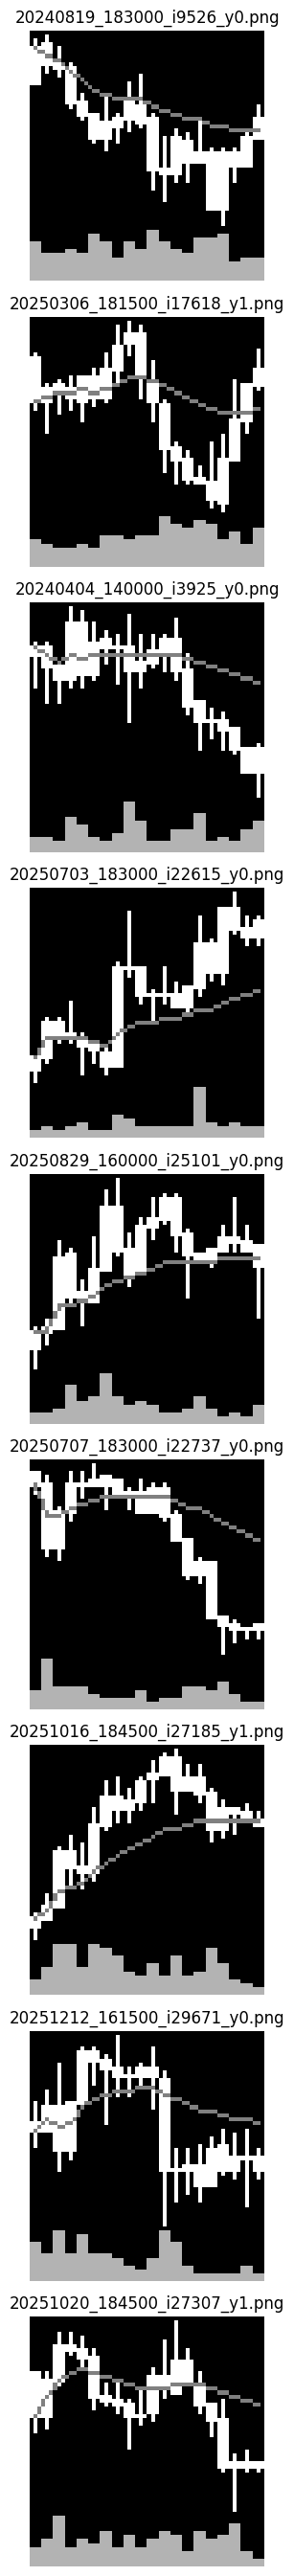

Previewed padded files:
/content/si_images_20bar_padded/train/20240819_183000_i9526_y0.png
/content/si_images_20bar_padded/train/20250306_181500_i17618_y1.png
/content/si_images_20bar_padded/train/20240404_140000_i3925_y0.png
/content/si_images_20bar_padded/val/20250703_183000_i22615_y0.png
/content/si_images_20bar_padded/val/20250829_160000_i25101_y0.png
/content/si_images_20bar_padded/val/20250707_183000_i22737_y0.png
/content/si_images_20bar_padded/test/20251016_184500_i27185_y1.png
/content/si_images_20bar_padded/test/20251212_161500_i29671_y0.png
/content/si_images_20bar_padded/test/20251020_184500_i27307_y1.png


In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

img_idx = pd.read_csv("/content/si_20bar_image_index_padded.csv")

preview_files = [
    "/content/si_images_20bar_padded/train/20240819_183000_i9526_y0.png",
    "/content/si_images_20bar_padded/train/20250306_181500_i17618_y1.png",
    "/content/si_images_20bar_padded/train/20240404_140000_i3925_y0.png",
    "/content/si_images_20bar_padded/val/20250703_183000_i22615_y0.png",
    "/content/si_images_20bar_padded/val/20250829_160000_i25101_y0.png",
    "/content/si_images_20bar_padded/val/20250707_183000_i22737_y0.png",
    "/content/si_images_20bar_padded/test/20251016_184500_i27185_y1.png",
    "/content/si_images_20bar_padded/test/20251212_161500_i29671_y0.png",
    "/content/si_images_20bar_padded/test/20251020_184500_i27307_y1.png",
]

fig, axes = plt.subplots(len(preview_files), 1, figsize=(8, 3 * len(preview_files)))
if len(preview_files) == 1:
    axes = [axes]

for ax, f in zip(axes, preview_files):
    img = Image.open(f)
    ax.imshow(img, cmap="gray")
    ax.set_title(f.split("/")[-1])
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Previewed padded files:")
for f in preview_files:
    print(f)

In [17]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Config
# -----------------------------
CSV_PATH = "/content/si_20bar_image_index_padded.csv"
MODEL_PATH = "/content/stockcnn_20bar_best.pt"

BATCH_SIZE = 64
EPOCHS = 12
LR = 1e-3
PATIENCE = 3
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Load manifest
# -----------------------------
df = pd.read_csv(CSV_PATH)
print("Manifest shape:", df.shape)
print(df["split"].value_counts())

# -----------------------------
# Dataset
# -----------------------------
class CandlestickImageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("L")
        arr = np.array(img, dtype=np.float32) / 255.0
        x = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)  # 1x64x60
        y = torch.tensor(int(row["label_20"]), dtype=torch.long)
        return x, y

train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

train_ds = CandlestickImageDataset(train_df)
val_ds   = CandlestickImageDataset(val_df)
test_ds  = CandlestickImageDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# -----------------------------
# Corrected 20-bar model
# -----------------------------
class StockCNN20(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 3), dilation=(2, 1)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(128, 256, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, 64, 60)
            feat = self.features(dummy)
            print("Feature map shape after conv blocks:", feat.shape)
            flat_dim = feat.view(1, -1).shape[1]
            print("Flatten dim:", flat_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_dim, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = StockCNN20().to(device)
print(model)

# -----------------------------
# Helpers
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.set_grad_enabled(train_mode):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total += xb.size(0)

    return total_loss / total, total_correct / total

# -----------------------------
# Train with early stopping
# -----------------------------
best_val_loss = float("inf")
best_epoch = -1
wait = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        wait = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print("\nBest epoch:", best_epoch)
print("Best val loss:", round(best_val_loss, 6))
print("Saved best model to:", MODEL_PATH)

# -----------------------------
# Final test evaluation
# -----------------------------
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
test_loss, test_acc = run_epoch(test_loader, train_mode=False)

print("\nFinal test metrics:")
print("test_loss:", round(test_loss, 6))
print("test_acc :", round(test_acc, 6))

hist_df = pd.DataFrame(history)
hist_path = "/content/stockcnn_20bar_train_history.csv"
hist_df.to_csv(hist_path, index=False)
print("Saved history to:", hist_path)

Using device: cpu
Manifest shape: (10350, 9)
split
train    7059
test     1646
val      1645
Name: count, dtype: int64
Feature map shape after conv blocks: torch.Size([1, 256, 4, 16])
Flatten dim: 16384
StockCNN20(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 3), dilation=(2, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01, inplace=True)
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01, inplace=True)
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(5, 3), stride=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [18]:
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Paths
# -----------------------------
CSV_PATH = "/content/si_20bar_image_index_padded.csv"
MODEL_PATH = "/content/stockcnn_20bar_best.pt"
OUT_PATH = "/content/stockcnn_20bar_test_predictions.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Load manifest
# -----------------------------
df = pd.read_csv(CSV_PATH)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Test rows:", len(test_df))

# -----------------------------
# Dataset
# -----------------------------
class CandlestickImageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("L")
        arr = np.array(img, dtype=np.float32) / 255.0
        x = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)  # 1x64x60
        y = torch.tensor(int(row["label_20"]), dtype=torch.long)
        return x, y

test_ds = CandlestickImageDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

# -----------------------------
# Same corrected model
# -----------------------------
class StockCNN20(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 3), dilation=(2, 1)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(128, 256, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, 64, 60)
            flat_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_dim, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = StockCNN20().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# -----------------------------
# Predict
# -----------------------------
all_probs = []
all_preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        p_up = probs[:, 1].cpu().numpy()
        pred = probs.argmax(dim=1).cpu().numpy()

        all_probs.extend(p_up.tolist())
        all_preds.extend(pred.tolist())

# -----------------------------
# Build output
# -----------------------------
out_df = test_df.copy()
out_df["cnn_p_up"] = all_probs
out_df["cnn_pred"] = all_preds
out_df["cnn_has_pred"] = True

# optional threshold-based version for later dashboard control
threshold = 0.50
out_df["cnn_pred_thr_050"] = (out_df["cnn_p_up"] >= threshold).astype(int)

out_df.to_csv(OUT_PATH, index=False)

print("Saved to:", OUT_PATH)
print("\nHead:")
print(
    out_df[
        ["sample_id", "anchor_time", "contract", "label_20", "forward_return_20", "cnn_p_up", "cnn_pred", "cnn_pred_thr_050"]
    ].head(10).to_string(index=False)
)

acc = (out_df["cnn_pred"] == out_df["label_20"]).mean()
print("\nTest accuracy from exported CSV:", round(acc, 6))

print("\nProbability summary:")
print(out_df["cnn_p_up"].describe())

Using device: cpu
Test rows: 1646
Saved to: /content/stockcnn_20bar_test_predictions.csv

Head:
 sample_id         anchor_time contract  label_20  forward_return_20  cnn_p_up  cnn_pred  cnn_pred_thr_050
      8704 2025-09-04 13:30:00     SiU5         1           0.000478  0.604225         1                 1
      8705 2025-09-04 13:45:00     SiU5         1           0.000992  0.653735         1                 1
      8706 2025-09-04 14:00:00     SiU5         1           0.001458  0.606862         1                 1
      8707 2025-09-04 14:15:00     SiU5         1           0.002550  0.506063         1                 1
      8708 2025-09-04 14:30:00     SiU5         1           0.001984  0.451459         0                 0
      8709 2025-09-04 14:45:00     SiU5         1           0.001837  0.543442         1                 1
      8710 2025-09-04 15:00:00     SiU5         1           0.001739  0.471098         0                 0
      8711 2025-09-04 15:15:00     SiU5         

In [21]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.cm as cm

import torch
import torch.nn as nn

# -----------------------------
# Paths
# -----------------------------
PRED_CSV = "/content/stockcnn_20bar_test_predictions.csv"
MODEL_PATH = "/content/stockcnn_20bar_best.pt"
OUT_DIR = Path("/content/si_gradcam_20bar_padded/test")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = "/content/stockcnn_20bar_test_predictions_with_gradcam.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Load predictions CSV
# -----------------------------
pred_df = pd.read_csv(PRED_CSV)
print("Test prediction rows:", len(pred_df))

# -----------------------------
# Corrected model for Grad-CAM
# -----------------------------
class StockCNN20(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 3), dilation=(2, 1)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01, inplace=False),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01, inplace=False),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(128, 256, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.01, inplace=False),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, 64, 60)
            flat_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_dim, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = StockCNN20().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# -----------------------------
# Hook last conv layer
# -----------------------------
activations = None
gradients = None

def forward_hook(module, inp, out):
    global activations
    activations = out.detach()

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

# last conv layer, before BN/ReLU/Pool
target_layer = model.features[8]

fh = target_layer.register_forward_hook(forward_hook)
bh = target_layer.register_full_backward_hook(backward_hook)

# -----------------------------
# Helpers
# -----------------------------
def load_input_tensor(img_path):
    img = Image.open(img_path).convert("L")
    arr = np.array(img, dtype=np.float32) / 255.0
    x = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # 1x1x64x60
    return x, img

def make_gradcam_overlay(gray_img_pil, cam_map, alpha=0.45):
    heat = cm.jet(cam_map)[:, :, :3]
    heat = (heat * 255).astype(np.uint8)
    heat_img = Image.fromarray(heat).convert("RGB")
    base = gray_img_pil.convert("RGB")
    overlay = Image.blend(base, heat_img, alpha=alpha)
    return overlay

# -----------------------------
# Generate Grad-CAM overlays
# -----------------------------
gradcam_paths = []

for i, row in pred_df.iterrows():
    img_path = row["image_path"]
    target_class = int(row["cnn_pred"])  # explain predicted class

    x, gray_img = load_input_tensor(img_path)
    x = x.to(device)

    model.zero_grad(set_to_none=True)
    logits = model(x)
    score = logits[0, target_class]
    score.backward()

    # activations / gradients from last conv layer
    a = activations[0]   # [C,H,W]
    g = gradients[0]     # [C,H,W]

    weights = g.mean(dim=(1, 2))  # [C]
    cam = torch.zeros(a.shape[1:], dtype=torch.float32, device=a.device)

    for c in range(a.shape[0]):
        cam += weights[c] * a[c]

    cam = torch.relu(cam)
    cam = cam.cpu().numpy()

    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    else:
        cam = np.zeros_like(cam, dtype=np.float32)

    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(gray_img.size, resample=Image.BILINEAR)
    cam_resized = np.array(cam_img, dtype=np.float32) / 255.0

    overlay = make_gradcam_overlay(gray_img, cam_resized, alpha=0.45)

    out_name = Path(img_path).name
    out_path = OUT_DIR / out_name
    overlay.save(out_path)

    gradcam_paths.append(str(out_path))

    if (i + 1) % 250 == 0:
        print(f"Processed {i+1}/{len(pred_df)}")

# -----------------------------
# Save updated CSV
# -----------------------------
pred_df["gradcam_path"] = gradcam_paths
pred_df.to_csv(OUT_CSV, index=False)

print("\nSaved Grad-CAM CSV to:", OUT_CSV)
print("Generated overlays:", len(gradcam_paths))
print("Grad-CAM folder:", str(OUT_DIR))

print("\nHead:")
print(
    pred_df[
        ["sample_id", "anchor_time", "contract", "label_20", "cnn_p_up", "cnn_pred", "gradcam_path"]
    ].head(10).to_string(index=False)
)

fh.remove()
bh.remove()

Using device: cpu
Test prediction rows: 1646
Processed 250/1646
Processed 500/1646
Processed 750/1646
Processed 1000/1646
Processed 1250/1646
Processed 1500/1646

Saved Grad-CAM CSV to: /content/stockcnn_20bar_test_predictions_with_gradcam.csv
Generated overlays: 1646
Grad-CAM folder: /content/si_gradcam_20bar_padded/test

Head:
 sample_id         anchor_time contract  label_20  cnn_p_up  cnn_pred                                                        gradcam_path
      8704 2025-09-04 13:30:00     SiU5         1  0.604225         1 /content/si_gradcam_20bar_padded/test/20250904_133000_i25335_y1.png
      8705 2025-09-04 13:45:00     SiU5         1  0.653735         1 /content/si_gradcam_20bar_padded/test/20250904_134500_i25336_y1.png
      8706 2025-09-04 14:00:00     SiU5         1  0.606862         1 /content/si_gradcam_20bar_padded/test/20250904_140000_i25337_y1.png
      8707 2025-09-04 14:15:00     SiU5         1  0.506063         1 /content/si_gradcam_20bar_padded/test/20250904_

Preview rows:
 sample_id         anchor_time contract  label_20  cnn_pred  cnn_p_up  forward_return_20                                                         image_path                                                        gradcam_path
      8704 2025-09-04 13:30:00     SiU5         1         1  0.604225           0.000478 /content/si_images_20bar_padded/test/20250904_133000_i25335_y1.png /content/si_gradcam_20bar_padded/test/20250904_133000_i25335_y1.png
      8705 2025-09-04 13:45:00     SiU5         1         1  0.653735           0.000992 /content/si_images_20bar_padded/test/20250904_134500_i25336_y1.png /content/si_gradcam_20bar_padded/test/20250904_134500_i25336_y1.png
      8706 2025-09-04 14:00:00     SiU5         1         1  0.606862           0.001458 /content/si_images_20bar_padded/test/20250904_140000_i25337_y1.png /content/si_gradcam_20bar_padded/test/20250904_140000_i25337_y1.png
      8708 2025-09-04 14:30:00     SiU5         1         0  0.451459           0.001984 /

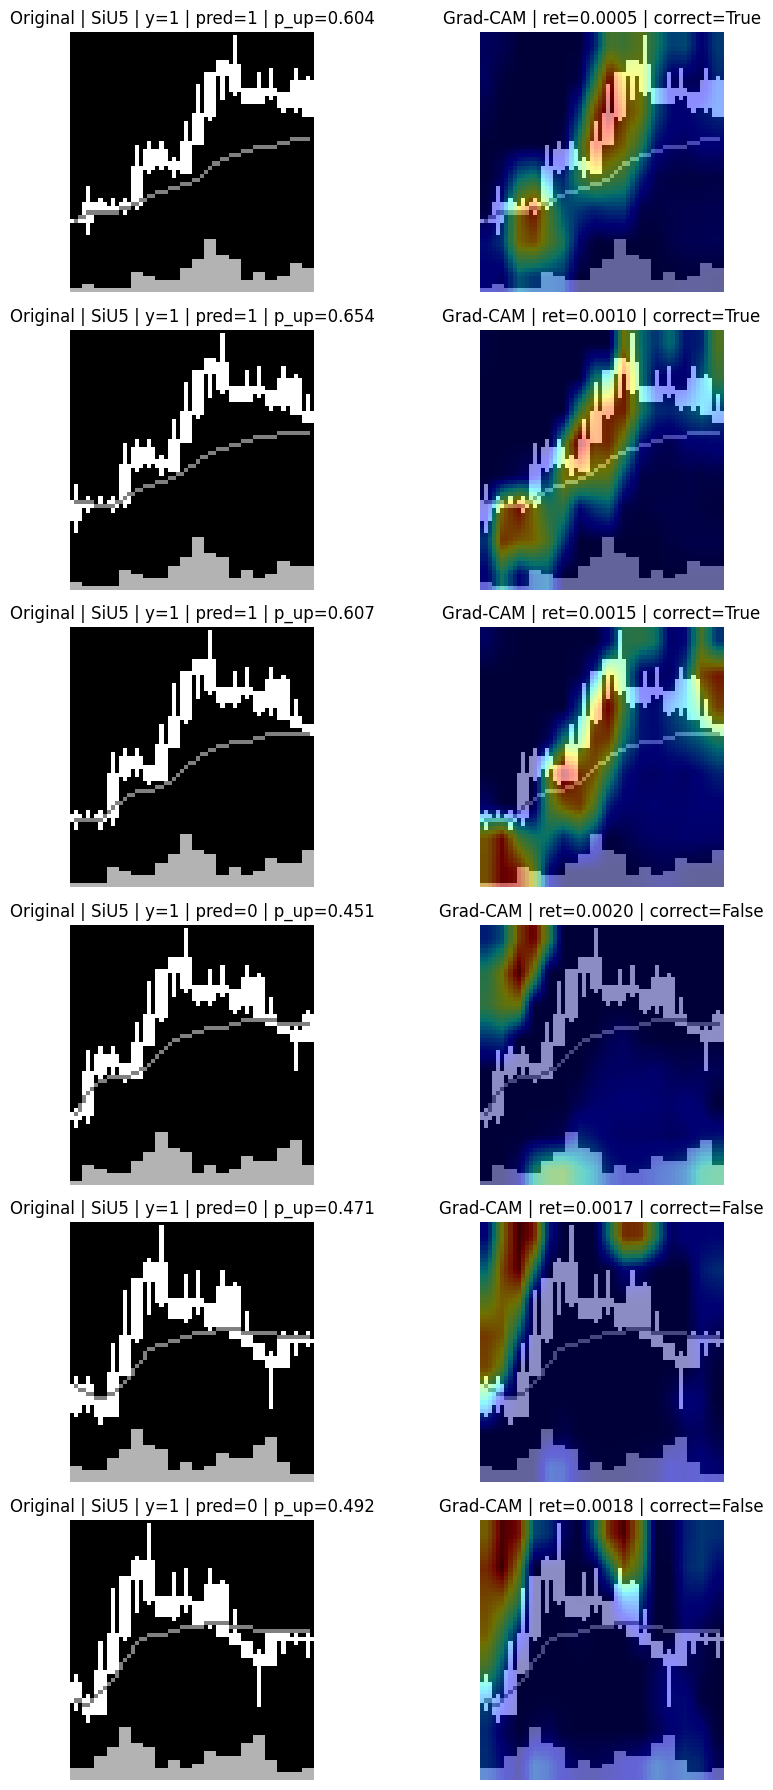

In [22]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Load final Grad-CAM CSV
df = pd.read_csv("/content/stockcnn_20bar_test_predictions_with_gradcam.csv")

# Pick a small mixed set:
# - first 3 correct predictions
# - first 3 wrong predictions
df["is_correct"] = (df["cnn_pred"] == df["label_20"])

correct_df = df[df["is_correct"]].head(3)
wrong_df   = df[~df["is_correct"]].head(3)

preview_df = pd.concat([correct_df, wrong_df], ignore_index=True)

print("Preview rows:")
print(
    preview_df[
        ["sample_id", "anchor_time", "contract", "label_20", "cnn_pred", "cnn_p_up", "forward_return_20", "image_path", "gradcam_path"]
    ].to_string(index=False)
)

# Plot original vs Grad-CAM
n = len(preview_df)
fig, axes = plt.subplots(n, 2, figsize=(10, 3 * n))

if n == 1:
    axes = [axes]

for i, (_, row) in enumerate(preview_df.iterrows()):
    orig = Image.open(row["image_path"]).convert("L")
    grad = Image.open(row["gradcam_path"]).convert("RGB")

    axes[i, 0].imshow(orig, cmap="gray")
    axes[i, 0].set_title(
        f"Original | {row['contract']} | y={row['label_20']} | pred={row['cnn_pred']} | p_up={row['cnn_p_up']:.3f}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(grad)
    axes[i, 1].set_title(
        f"Grad-CAM | ret={row['forward_return_20']:.4f} | correct={row['is_correct']}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [23]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.cm as cm

import torch
import torch.nn as nn

# =========================================================
# CONFIG
# =========================================================
PRED_CSV   = "/content/stockcnn_20bar_test_predictions.csv"
MODEL_PATH = "/content/stockcnn_20bar_best.pt"

OUT_DIR_RAW    = Path("/content/si_xai_final/raw_overlay")
OUT_DIR_MASKED = Path("/content/si_xai_final/masked_overlay")
OUT_DIR_HEAT   = Path("/content/si_xai_final/heatmap_only")

OUT_DIR_RAW.mkdir(parents=True, exist_ok=True)
OUT_DIR_MASKED.mkdir(parents=True, exist_ok=True)
OUT_DIR_HEAT.mkdir(parents=True, exist_ok=True)

OUT_CSV = "/content/stockcnn_20bar_test_predictions_xai_final.csv"

IMG_H = 64
IMG_W = 60
PRICE_H = 51
VOL_H = 13

# SmoothGrad-CAM settings
N_SMOOTH = 8         # if CPU is slow, reduce to 4
NOISE_STD = 0.03     # input noise std on [0,1] normalized image
ALPHA_RAW = 0.45
ALPHA_MASKED = 0.55

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# LOAD TEST PREDICTIONS
# =========================================================
pred_df = pd.read_csv(PRED_CSV)
print("Rows in prediction CSV:", len(pred_df))

# =========================================================
# MODEL (same architecture, inplace=False for hooks safety)
# =========================================================
class StockCNN20(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(5, 3), stride=(1, 3), dilation=(2, 1)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.01, inplace=False),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.01, inplace=False),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(128, 256, kernel_size=(5, 3), stride=(1, 1), dilation=(1, 1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.01, inplace=False),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, 64, 60)
            flat_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_dim, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = StockCNN20().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# =========================================================
# HOOK LAST CONV LAYER
# =========================================================
activations = None
gradients = None

def forward_hook(module, inp, out):
    global activations
    activations = out

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.features[8]  # last Conv2d
fh = target_layer.register_forward_hook(forward_hook)
bh = target_layer.register_full_backward_hook(backward_hook)

# =========================================================
# HELPERS
# =========================================================
def load_input_tensor(img_path):
    img = Image.open(img_path).convert("L")
    arr = np.array(img, dtype=np.float32) / 255.0
    x = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # 1x1x64x60
    return x, img, arr

def normalize_cam(cam):
    cam = np.maximum(cam, 0)
    if cam.max() > cam.min():
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    else:
        cam = np.zeros_like(cam, dtype=np.float32)
    return cam

def resize_cam_to_image(cam, size):
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(size, resample=Image.BILINEAR)
    return np.array(cam_img, dtype=np.float32) / 255.0

def make_heat_rgb(cam_resized):
    heat = cm.jet(cam_resized)[:, :, :3]
    return (heat * 255).astype(np.uint8)

def save_raw_overlay(gray_img_pil, cam_resized, out_path, alpha=0.45):
    heat_rgb = Image.fromarray(make_heat_rgb(cam_resized)).convert("RGB")
    base_rgb = gray_img_pil.convert("RGB")
    overlay = Image.blend(base_rgb, heat_rgb, alpha=alpha)
    overlay.save(out_path)

def save_masked_overlay(gray_img_pil, cam_resized, foreground_mask, out_path, alpha=0.55):
    base = np.array(gray_img_pil.convert("RGB"), dtype=np.uint8)
    heat = make_heat_rgb(cam_resized)

    # only show heat where there is actual chart content
    mask3 = np.repeat(foreground_mask[:, :, None], 3, axis=2)
    blended = base.copy()
    blended[mask3] = (
        (1 - alpha) * base[mask3] + alpha * heat[mask3]
    ).astype(np.uint8)

    Image.fromarray(blended).save(out_path)

def save_heat_only(cam_resized, out_path):
    heat = make_heat_rgb(cam_resized)
    Image.fromarray(heat).save(out_path)

def compute_attention_metrics(cam_resized, gray_arr):
    eps = 1e-12
    cam_mass = cam_resized.astype(np.float64)
    s = cam_mass.sum()
    if s <= eps:
        cam_mass[:] = 0.0
    else:
        cam_mass /= s

    # chart-content mask
    foreground_mask = gray_arr > 0.05
    background_mask = ~foreground_mask

    # structural regions
    price_area_mask = np.zeros_like(cam_mass, dtype=bool)
    price_area_mask[:PRICE_H, :] = True

    volume_area_mask = np.zeros_like(cam_mass, dtype=bool)
    volume_area_mask[PRICE_H:, :] = True

    # recent-bars areas (5 bars = 15 px, 1 bar = 3 px)
    recent_5_mask = np.zeros_like(cam_mass, dtype=bool)
    recent_5_mask[:, -15:] = True

    last_bar_mask = np.zeros_like(cam_mass, dtype=bool)
    last_bar_mask[:, -3:] = True

    metrics = {
        "heat_on_foreground": float(cam_mass[foreground_mask].sum()),
        "heat_on_background": float(cam_mass[background_mask].sum()),
        "heat_on_price_area": float(cam_mass[price_area_mask].sum()),
        "heat_on_volume_area": float(cam_mass[volume_area_mask].sum()),
        "heat_on_recent_5bars": float(cam_mass[recent_5_mask].sum()),
        "heat_on_last_bar": float(cam_mass[last_bar_mask].sum()),
    }

    # heuristic ranking score for dashboard triage only
    metrics["xai_quality_score"] = float(
        0.45 * metrics["heat_on_foreground"] +
        0.35 * metrics["heat_on_price_area"] +
        0.20 * metrics["heat_on_recent_5bars"]
    )

    return metrics, foreground_mask

def smooth_gradcam(x, target_class, n_smooth=8, noise_std=0.03):
    """
    SmoothGrad-CAM:
    average CAM over noisy versions of the same input.
    """
    cams = []

    for _ in range(n_smooth):
        noise = torch.randn_like(x) * noise_std
        x_noisy = torch.clamp(x + noise, 0.0, 1.0)

        model.zero_grad(set_to_none=True)
        logits = model(x_noisy)
        score = logits[0, target_class]
        score.backward(retain_graph=False)

        a = activations[0]  # [C,H,W]
        g = gradients[0]    # [C,H,W]

        weights = g.mean(dim=(1, 2))  # [C]
        cam_t = torch.zeros(a.shape[1:], dtype=torch.float32, device=a.device)
        for c in range(a.shape[0]):
            cam_t += weights[c] * a[c]

        cam_np = cam_t.detach().cpu().numpy()
        cam_np = normalize_cam(cam_np)
        cams.append(cam_np)

    cam_avg = np.mean(np.stack(cams, axis=0), axis=0)
    cam_avg = normalize_cam(cam_avg)
    return cam_avg

# =========================================================
# GENERATE FINAL XAI ARTIFACTS
# =========================================================
raw_paths = []
masked_paths = []
heat_paths = []

metrics_rows = []

for i, row in pred_df.iterrows():
    img_path = row["image_path"]
    target_class = int(row["cnn_pred"])   # explain predicted class

    x, gray_img, gray_arr = load_input_tensor(img_path)
    x = x.to(device)

    # SmoothGrad-CAM
    cam_small = smooth_gradcam(x, target_class, n_smooth=N_SMOOTH, noise_std=NOISE_STD)
    cam_resized = resize_cam_to_image(cam_small, gray_img.size)

    # metrics + mask
    metrics, foreground_mask = compute_attention_metrics(cam_resized, gray_arr)

    # save files
    fname = Path(img_path).name

    raw_path = OUT_DIR_RAW / fname
    masked_path = OUT_DIR_MASKED / fname
    heat_path = OUT_DIR_HEAT / fname

    save_raw_overlay(gray_img, cam_resized, raw_path, alpha=ALPHA_RAW)
    save_masked_overlay(gray_img, cam_resized, foreground_mask, masked_path, alpha=ALPHA_MASKED)
    save_heat_only(cam_resized, heat_path)

    raw_paths.append(str(raw_path))
    masked_paths.append(str(masked_path))
    heat_paths.append(str(heat_path))
    metrics_rows.append(metrics)

    if (i + 1) % 100 == 0:
        print(f"Processed {i+1}/{len(pred_df)}")

# =========================================================
# SAVE FINAL MASTER CSV
# =========================================================
metrics_df = pd.DataFrame(metrics_rows)
final_df = pd.concat([pred_df.reset_index(drop=True), metrics_df], axis=1)

final_df["gradcam_raw_path"] = raw_paths
final_df["gradcam_masked_path"] = masked_paths
final_df["gradcam_heat_path"] = heat_paths
final_df["is_correct"] = (final_df["cnn_pred"] == final_df["label_20"])

final_df.to_csv(OUT_CSV, index=False)

print("\nSaved final XAI CSV to:", OUT_CSV)
print("Rows:", len(final_df))

print("\nMetric summary:")
metric_cols = [
    "heat_on_foreground",
    "heat_on_background",
    "heat_on_price_area",
    "heat_on_volume_area",
    "heat_on_recent_5bars",
    "heat_on_last_bar",
    "xai_quality_score"
]
print(final_df[metric_cols].describe().to_string())

print("\nTop 10 by heuristic XAI quality score:")
top10 = final_df.sort_values("xai_quality_score", ascending=False).head(10)
print(
    top10[
        ["sample_id", "anchor_time", "contract", "label_20", "cnn_pred", "cnn_p_up",
         "is_correct", "xai_quality_score", "heat_on_foreground",
         "heat_on_price_area", "heat_on_recent_5bars", "gradcam_masked_path"]
    ].to_string(index=False)
)

# cleanup hooks
fh.remove()
bh.remove()

Using device: cpu
Rows in prediction CSV: 1646
Processed 100/1646
Processed 200/1646
Processed 300/1646
Processed 400/1646
Processed 500/1646
Processed 600/1646
Processed 700/1646
Processed 800/1646
Processed 900/1646
Processed 1000/1646
Processed 1100/1646
Processed 1200/1646
Processed 1300/1646
Processed 1400/1646
Processed 1500/1646
Processed 1600/1646

Saved final XAI CSV to: /content/stockcnn_20bar_test_predictions_xai_final.csv
Rows: 1646

Metric summary:
       heat_on_foreground  heat_on_background  heat_on_price_area  heat_on_volume_area  heat_on_recent_5bars  heat_on_last_bar  xai_quality_score
count         1646.000000         1646.000000         1646.000000          1646.000000           1646.000000       1646.000000        1646.000000
mean             0.264392            0.735608            0.807255             0.192745              0.205216          0.042779           0.442559
std              0.072387            0.072387            0.121717             0.121717          

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# PATHS
# =========================================================
XAI_CSV = "/content/stockcnn_20bar_test_predictions_xai_final.csv"
OUT_DIR = Path("/content/dashboard_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_CSV = OUT_DIR / "dashboard_master.csv"
SUMMARY_SPLIT_CSV = OUT_DIR / "dashboard_summary_by_split.csv"
SUMMARY_CONTRACT_CSV = OUT_DIR / "dashboard_summary_by_contract.csv"
SUMMARY_XAI_CSV = OUT_DIR / "dashboard_xai_quality_buckets.csv"

# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(XAI_CSV)
df["anchor_time"] = pd.to_datetime(df["anchor_time"])

print("Loaded rows:", len(df))

# =========================================================
# DERIVED FIELDS
# =========================================================

# correctness
df["is_correct"] = (df["cnn_pred"] == df["label_20"])

def error_type(row):
    y = int(row["label_20"])
    p = int(row["cnn_pred"])
    if y == 1 and p == 1:
        return "TP"
    elif y == 0 and p == 0:
        return "TN"
    elif y == 0 and p == 1:
        return "FP"
    elif y == 1 and p == 0:
        return "FN"
    return "UNK"

df["error_type"] = df.apply(error_type, axis=1)

# model confidence
df["cnn_confidence"] = np.where(df["cnn_pred"] == 1, df["cnn_p_up"], 1 - df["cnn_p_up"])

def confidence_bucket(x):
    if x >= 0.80:
        return "very_high"
    elif x >= 0.65:
        return "high"
    elif x >= 0.55:
        return "medium"
    else:
        return "low"

df["confidence_bucket"] = df["cnn_confidence"].apply(confidence_bucket)

# simple trading signal buckets for dashboard filtering
# purely for exploration, not final backtest proof
def signal_bucket(p):
    if p >= 0.60:
        return "long_strong"
    elif p >= 0.55:
        return "long_weak"
    elif p <= 0.40:
        return "short_strong"
    elif p <= 0.45:
        return "short_weak"
    else:
        return "neutral"

df["signal_bucket"] = df["cnn_p_up"].apply(signal_bucket)

# XAI quality bucket
def xai_bucket(x):
    if x >= 0.55:
        return "high"
    elif x >= 0.45:
        return "medium"
    else:
        return "low"

df["xai_quality_bucket"] = df["xai_quality_score"].apply(xai_bucket)

# rank within full test set
df["rank_confidence"] = df["cnn_confidence"].rank(method="dense", ascending=False).astype(int)
df["rank_xai_quality"] = df["xai_quality_score"].rank(method="dense", ascending=False).astype(int)

# =========================================================
# DASHBOARD SURFACING RULE
# Keep only better examples surfaced by default:
# - correct + medium/high confidence + medium/high xai
# - OR any very high confidence mistake (important for diagnostics)
# =========================================================
df["show_in_dashboard"] = False

mask_good = (
    df["is_correct"] &
    df["confidence_bucket"].isin(["medium", "high", "very_high"]) &
    df["xai_quality_bucket"].isin(["medium", "high"])
)

mask_important_errors = (
    (~df["is_correct"]) &
    df["confidence_bucket"].isin(["high", "very_high"])
)

df.loc[mask_good | mask_important_errors, "show_in_dashboard"] = True

# =========================================================
# SUMMARIES
# =========================================================
summary_by_split = (
    df.groupby("split", as_index=False)
      .agg(
          rows=("sample_id", "size"),
          acc=("is_correct", "mean"),
          avg_p_up=("cnn_p_up", "mean"),
          avg_confidence=("cnn_confidence", "mean"),
          avg_xai_quality=("xai_quality_score", "mean"),
          avg_heat_foreground=("heat_on_foreground", "mean"),
          avg_heat_background=("heat_on_background", "mean"),
          avg_heat_price=("heat_on_price_area", "mean"),
          avg_heat_volume=("heat_on_volume_area", "mean"),
      )
)

summary_by_contract = (
    df.groupby("contract", as_index=False)
      .agg(
          rows=("sample_id", "size"),
          acc=("is_correct", "mean"),
          avg_p_up=("cnn_p_up", "mean"),
          avg_confidence=("cnn_confidence", "mean"),
          avg_xai_quality=("xai_quality_score", "mean"),
          avg_fwd_ret=("forward_return_20", "mean"),
      )
      .sort_values("rows", ascending=False)
)

summary_xai = (
    df.groupby(["xai_quality_bucket", "error_type"], as_index=False)
      .agg(
          rows=("sample_id", "size"),
          avg_confidence=("cnn_confidence", "mean"),
          avg_p_up=("cnn_p_up", "mean"),
          avg_heat_foreground=("heat_on_foreground", "mean"),
          avg_heat_background=("heat_on_background", "mean"),
      )
      .sort_values(["xai_quality_bucket", "error_type"])
)

# =========================================================
# SAVE
# =========================================================
df.to_csv(MASTER_CSV, index=False)
summary_by_split.to_csv(SUMMARY_SPLIT_CSV, index=False)
summary_by_contract.to_csv(SUMMARY_CONTRACT_CSV, index=False)
summary_xai.to_csv(SUMMARY_XAI_CSV, index=False)

# =========================================================
# OUTPUT
# =========================================================
print("\nSaved files:")
print(" -", MASTER_CSV)
print(" -", SUMMARY_SPLIT_CSV)
print(" -", SUMMARY_CONTRACT_CSV)
print(" -", SUMMARY_XAI_CSV)

print("\nDashboard master shape:", df.shape)

print("\nRows surfaced by default in dashboard:", int(df["show_in_dashboard"].sum()))

print("\nSummary by split:")
print(summary_by_split.to_string(index=False))

print("\nSummary by contract:")
print(summary_by_contract.to_string(index=False))

print("\nTop 15 surfaced examples:")
cols = [
    "sample_id", "anchor_time", "contract", "label_20", "cnn_pred",
    "cnn_p_up", "cnn_confidence", "error_type",
    "xai_quality_score", "xai_quality_bucket", "show_in_dashboard",
    "image_path", "gradcam_masked_path"
]
print(
    df[df["show_in_dashboard"]]
    .sort_values(["cnn_confidence", "xai_quality_score"], ascending=False)
    .head(15)[cols]
    .to_string(index=False)
)

Loaded rows: 1646

Saved files:
 - /content/dashboard_final/dashboard_master.csv
 - /content/dashboard_final/dashboard_summary_by_split.csv
 - /content/dashboard_final/dashboard_summary_by_contract.csv
 - /content/dashboard_final/dashboard_xai_quality_buckets.csv

Dashboard master shape: (1646, 32)

Rows surfaced by default in dashboard: 498

Summary by split:
split  rows      acc  avg_p_up  avg_confidence  avg_xai_quality  avg_heat_foreground  avg_heat_background  avg_heat_price  avg_heat_volume
 test  1646 0.552248  0.443857        0.621048         0.442559             0.264392             0.735608        0.807255         0.192745

Summary by contract:
contract  rows      acc  avg_p_up  avg_confidence  avg_xai_quality  avg_fwd_ret
    SiZ5  1449 0.563837  0.442460        0.623657         0.443148    -0.000878
    SiU5   197 0.467005  0.454129        0.601860         0.438227     0.001012

Top 15 surfaced examples:
 sample_id         anchor_time contract  label_20  cnn_pred  cnn_p_up 

In [25]:
import os
import zipfile
from pathlib import Path

paths_to_include = [
    "/content/dashboard_final",
    "/content/stockcnn_20bar_best.pt",
    "/content/stockcnn_20bar_train_history.csv",
    "/content/stockcnn_20bar_test_predictions.csv",
    "/content/stockcnn_20bar_test_predictions_with_gradcam.csv",
    "/content/stockcnn_20bar_test_predictions_xai_final.csv",
    "/content/si_20bar_samples_index.csv",
    "/content/si_20bar_samples_index_split.csv",
    "/content/si_20bar_image_index.csv",
    "/content/si_20bar_image_index_padded.csv",
    "/content/si_candles_merged_long.csv",
    "/content/si_candles_15m_by_contract.csv",
    "/content/si_front_daily_contracts.csv",
    "/content/si_front_daily_contracts_clean.csv",
    "/content/si_continuous_front_15m.csv",
    "/content/si_continuous_front_15m_clean.csv",
    "/content/si_images_20bar_padded",
    "/content/si_gradcam_20bar_padded",
    "/content/si_xai_final",
]

zip_path = "/content/thesis_dashboard_all_files.zip"

def add_path_to_zip(zf, src_path, arc_base=""):
    src = Path(src_path)
    if not src.exists():
        print(f"[SKIP missing] {src}")
        return
    if src.is_file():
        arcname = str(Path(arc_base) / src.name) if arc_base else src.name
        zf.write(src, arcname=arcname)
        print(f"[FILE] {src} -> {arcname}")
    else:
        for root, _, files in os.walk(src):
            for fname in files:
                fpath = Path(root) / fname
                arcname = str(Path(arc_base) / fpath.relative_to(src.parent))
                zf.write(fpath, arcname=arcname)
        print(f"[DIR ] {src}")

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in paths_to_include:
        add_path_to_zip(zf, p)

print("\nSaved zip to:", zip_path)
print("Zip size (MB):", round(Path(zip_path).stat().st_size / (1024 * 1024), 2))

[DIR ] /content/dashboard_final
[FILE] /content/stockcnn_20bar_best.pt -> stockcnn_20bar_best.pt
[FILE] /content/stockcnn_20bar_train_history.csv -> stockcnn_20bar_train_history.csv
[FILE] /content/stockcnn_20bar_test_predictions.csv -> stockcnn_20bar_test_predictions.csv
[FILE] /content/stockcnn_20bar_test_predictions_with_gradcam.csv -> stockcnn_20bar_test_predictions_with_gradcam.csv
[FILE] /content/stockcnn_20bar_test_predictions_xai_final.csv -> stockcnn_20bar_test_predictions_xai_final.csv
[FILE] /content/si_20bar_samples_index.csv -> si_20bar_samples_index.csv
[FILE] /content/si_20bar_samples_index_split.csv -> si_20bar_samples_index_split.csv
[FILE] /content/si_20bar_image_index.csv -> si_20bar_image_index.csv
[FILE] /content/si_20bar_image_index_padded.csv -> si_20bar_image_index_padded.csv
[FILE] /content/si_candles_merged_long.csv -> si_candles_merged_long.csv
[FILE] /content/si_candles_15m_by_contract.csv -> si_candles_15m_by_contract.csv
[FILE] /content/si_front_daily_cont

In [26]:
import os
import shutil
from pathlib import Path
from google.colab import files

# =========================================================
# CONFIG
# =========================================================
PACKAGE_DIR = Path("/content/thesis_dashboard_package")
ZIP_PATH = Path("/content/thesis_dashboard_package.zip")

# clean old package if exists
if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# FILES / FOLDERS TO INCLUDE
# =========================================================
items_to_copy = [
    # core merged / processed data
    "/content/si_candles_merged_long.csv",
    "/content/si_candles_15m_by_contract.csv",
    "/content/si_front_daily_contracts.csv",
    "/content/si_front_daily_contracts_clean.csv",
    "/content/si_continuous_front_15m.csv",
    "/content/si_continuous_front_15m_clean.csv",

    # sample/index files
    "/content/si_20bar_samples_index.csv",
    "/content/si_20bar_samples_index_split.csv",
    "/content/si_20bar_image_index.csv",
    "/content/si_20bar_image_index_padded.csv",

    # model outputs
    "/content/stockcnn_20bar_best.pt",
    "/content/stockcnn_20bar_train_history.csv",
    "/content/stockcnn_20bar_test_predictions.csv",
    "/content/stockcnn_20bar_test_predictions_with_gradcam.csv",
    "/content/stockcnn_20bar_test_predictions_xai_final.csv",

    # dashboard-ready files
    "/content/dashboard_final/dashboard_master.csv",
    "/content/dashboard_final/dashboard_summary_by_split.csv",
    "/content/dashboard_final/dashboard_summary_by_contract.csv",
    "/content/dashboard_final/dashboard_xai_quality_buckets.csv",

    # image folders
    "/content/si_images_20bar_padded",
    "/content/si_gradcam_20bar_padded",
    "/content/si_xai_final",
]

# =========================================================
# COPY
# =========================================================
copied = []
missing = []

for item in items_to_copy:
    src = Path(item)
    if src.exists():
        dst = PACKAGE_DIR / src.name
        if src.is_dir():
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
        copied.append(str(src))
    else:
        missing.append(str(src))

print("Copied items:", len(copied))
for c in copied:
    print(" -", c)

if missing:
    print("\nMissing items:", len(missing))
    for m in missing:
        print(" -", m)

# =========================================================
# WRITE A SIMPLE README
# =========================================================
readme_text = """Thesis Dashboard Package

Contents:
- merged and resampled futures data
- front-contract mapping and cleaned continuous front series
- 20-bar sample index and split files
- 20-bar image index files
- trained CNN model and training history
- test predictions
- Grad-CAM / XAI outputs
- dashboard-ready master CSV and summary CSVs

Suggested key file for dashboard:
- dashboard_master.csv

Suggested key folders for visuals:
- si_images_20bar_padded
- si_gradcam_20bar_padded
- si_xai_final
"""

(PACKAGE_DIR / "README.txt").write_text(readme_text, encoding="utf-8")

# =========================================================
# ZIP
# =========================================================
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive("/content/thesis_dashboard_package", "zip", root_dir=PACKAGE_DIR)

print("\nZIP created:", ZIP_PATH)
print("ZIP size (MB):", round(ZIP_PATH.stat().st_size / (1024 * 1024), 2))

# =========================================================
# AUTO DOWNLOAD
# =========================================================
files.download(str(ZIP_PATH))

Copied items: 22
 - /content/si_candles_merged_long.csv
 - /content/si_candles_15m_by_contract.csv
 - /content/si_front_daily_contracts.csv
 - /content/si_front_daily_contracts_clean.csv
 - /content/si_continuous_front_15m.csv
 - /content/si_continuous_front_15m_clean.csv
 - /content/si_20bar_samples_index.csv
 - /content/si_20bar_samples_index_split.csv
 - /content/si_20bar_image_index.csv
 - /content/si_20bar_image_index_padded.csv
 - /content/stockcnn_20bar_best.pt
 - /content/stockcnn_20bar_train_history.csv
 - /content/stockcnn_20bar_test_predictions.csv
 - /content/stockcnn_20bar_test_predictions_with_gradcam.csv
 - /content/stockcnn_20bar_test_predictions_xai_final.csv
 - /content/dashboard_final/dashboard_master.csv
 - /content/dashboard_final/dashboard_summary_by_split.csv
 - /content/dashboard_final/dashboard_summary_by_contract.csv
 - /content/dashboard_final/dashboard_xai_quality_buckets.csv
 - /content/si_images_20bar_padded
 - /content/si_gradcam_20bar_padded
 - /content/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>